In [ ]:
#task 1 load data
import pandas as pd

# Load the dataset (replace 'laptops.csv' with your file path)
df = pd.read_csv('laptop_data.csv')

# View the first 5 rows
print("--- First 5 Rows ---")
print(df.head())

# Get basic information about columns and data types
print("\n--- Dataset Info ---")
print(df.info())
print(df.describe())

In [3]:
#task 2 Null value analysis
import pandas as pd

df = pd.read_csv("laptop_data.csv")
missing_count = df.isnull().sum()
missing_percentage = (df.isnull().sum() / df.shape[0]) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage.round(2)
})

print(missing_summary)
high_null = missing_summary[missing_summary["Missing Percentage"] > 20]

print("Columns with more than 20% missing values:")
print(high_null)
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    null_percent = (df[col].isnull().sum() / len(df)) * 100

    if null_percent <= 20:
        df[col] = df[col].fillna(df[col].median())

print("Missing values filled.")
remaining_nulls = df.isnull().sum()

print(remaining_nulls[remaining_nulls > 0])


                  Missing Count  Missing Percentage
sno                           0                0.00
Company                       0                0.00
TypeName                      0                0.00
Inches                        1                0.08
ScreenResolution              0                0.00
Cpu                           0                0.00
Ram                          29                2.22
Memory                       37                2.84
Gpu                           0                0.00
OpSys                         0                0.00
Weight                        0                0.00
Price                         0                0.00
Columns with more than 20% missing values:
Empty DataFrame
Columns: [Missing Count, Missing Percentage]
Index: []
Missing values filled.
Ram       29
Memory    37
dtype: int64


In [5]:
#task 3 Duplicate detection and removal
# Count duplicate rows

df = pd.read_csv('laptop_data.csv')
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [7]:
# task 3Count duplicate rows
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

# Null percentage before removing duplicates
null_before = (df.isnull().sum() / len(df)) * 100

# Remove duplicate rows
df_clean = df.drop_duplicates()

# Count rows removed
rows_removed = len(df) - len(df_clean)
print("Rows removed:", rows_removed)

# Null percentage after removing duplicates
null_after = (df_clean.isnull().sum() / len(df_clean)) * 100

# Compare null percentages
comparison = pd.DataFrame({
    "Before (%)": null_before.round(2),
    "After (%)": null_after.round(2)
})

print(comparison)

# Check whether null percentages changed
if null_before.equals(null_after):
    print("Null percentages did not change after removing duplicates.")
else:
    print("Null percentages changed after removing duplicates.")


Duplicate rows: 0
Rows removed: 0
                  Before (%)  After (%)
sno                     0.00       0.00
Company                 0.00       0.00
TypeName                0.00       0.00
Inches                  0.08       0.08
ScreenResolution        0.00       0.00
Cpu                     0.00       0.00
Ram                     2.22       2.22
Memory                  2.84       2.84
Gpu                     0.00       0.00
OpSys                   0.00       0.00
Weight                  0.00       0.00
Price                   0.00       0.00
Null percentages did not change after removing duplicates.


In [42]:
#task 4data type correction
import pandas as pd

# Load dataset
df = pd.read_csv("laptop_data1.csv")

# Display original data types
print("Original Data Types:\n")
print(df.dtypes)

# Memory usage before conversion
memory_before = df.memory_usage(deep=True).sum()
print("\nMemory usage before conversion:", memory_before, "bytes")

# -----------------------------
# Data Type Corrections
# -----------------------------

# Convert Ram from object (e.g., '8GB') to numeric
df["Ram"] = pd.to_numeric(
    df["Ram"].str.replace("GB", "", regex=False),
    errors="coerce"
)

# Convert repetitive string columns to category
df["Company"] = df["Company"].astype("category")
df["TypeName"] = df["TypeName"].astype("category")
df["OpSys"] = df["OpSys"].astype("category")

# -----------------------------
# Display updated data types
# -----------------------------

print("\nUpdated Data Types:\n")
print(df.dtypes)

# Memory usage after conversion
memory_after = df.memory_usage(deep=True).sum()
print("\nMemory usage after conversion:", memory_after, "bytes")

# Memory saved
print("Memory saved:", memory_before - memory_after, "bytes")
#["Company"] = df["Company"].astype("category"

Original Data Types:

sno                   int64
Company              object
TypeName             object
Inches              float64
ScreenResolution     object
Cpu                  object
Ram                  object
Memory               object
Gpu                  object
OpSys                object
Weight               object
Price               float64
dtype: object

Memory usage before conversion: 747009 bytes

Updated Data Types:

sno                    int64
Company             category
TypeName            category
Inches               float64
ScreenResolution      object
Cpu                   object
Ram                  float64
Memory                object
Gpu                   object
OpSys               category
Weight                object
Price                float64
dtype: object

Memory usage after conversion: 475910 bytes
Memory saved: 271099 bytes


In [43]:
#task 5 descriptive stat (skew)
df = pd.read_csv("laptop_data1.csv")
df["Ram"] = pd.to_numeric(df["Ram"].str.replace("GB", "", regex=False), errors="coerce")
print(df.describe())
skewness = df.select_dtypes(include="number").skew()

print("Skewness of numeric columns:\n")
print(skewness)
highest_skew_col = skewness.abs().idxmax()
highest_skew_value = skewness[highest_skew_col]

print("\nColumn with highest absolute skewness:", highest_skew_col)
print("Skewness value:", highest_skew_value)

               sno       Inches          Ram          Price
count  1304.000000  1303.000000  1274.000000    1304.000000
mean    651.496933    15.005295     8.353218   59859.795213
std     376.581972     1.486838     5.125683   37227.281050
min       0.000000     0.000000     0.000000    9270.720000
25%     325.750000    14.000000     4.000000   31914.720000
50%     651.500000    15.600000     8.000000   52054.560000
75%     977.250000    15.600000     8.000000   79244.676000
max    1303.000000    18.400000    64.000000  324954.720000
Skewness of numeric columns:

sno      -0.000048
Inches   -1.166280
Ram       2.673432
Price     1.522797
dtype: float64

Column with highest absolute skewness: Ram
Skewness value: 2.6734324159853955


In [44]:
#task 6  outlier detection
import pandas as pd

df = pd.read_csv("laptop_data.csv")

# Convert Ram to numeric
df["Ram"] = pd.to_numeric(df["Ram"].str.replace("GB", "", regex=False), errors="coerce")
# Numeric columns to analyze
columns = ["Price", "Ram"]

for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print("\nColumn:", col)
    print("Q1 =", Q1)
    print("Q3 =", Q3)
    print("IQR =", IQR)
    print("Lower Bound =", lower_bound)
    print("Upper Bound =", upper_bound)
    print("Number of Outliers =", len(outliers))


Column: Price
Q1 = 31914.72
Q3 = 79346.8404
IQR = 47432.1204
Lower Bound = -39233.46059999999
Upper Bound = 150495.021
Number of Outliers = 28

Column: Ram
Q1 = 4.0
Q3 = 8.0
IQR = 4.0
Lower Bound = -2.0
Upper Bound = 14.0
Number of Outliers = 222


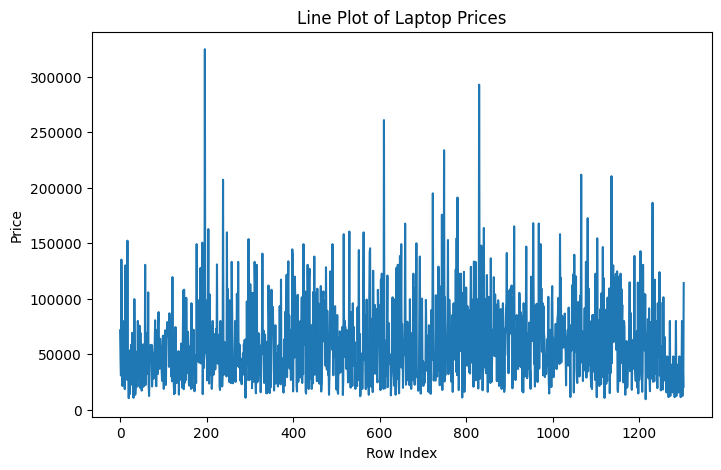

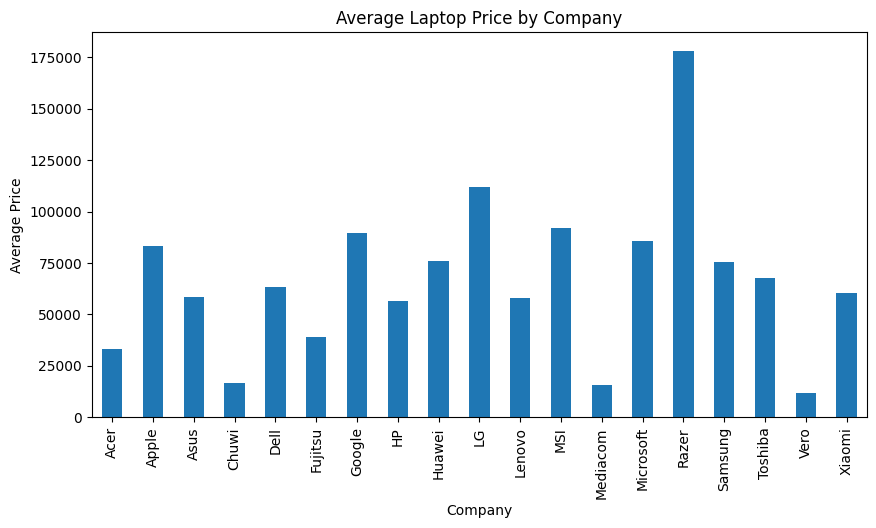

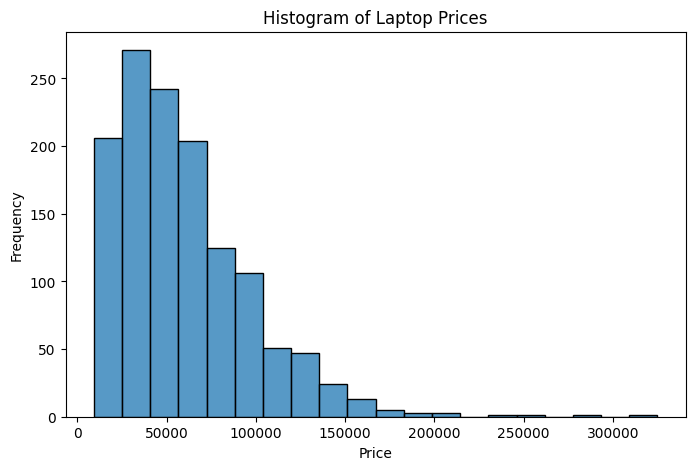

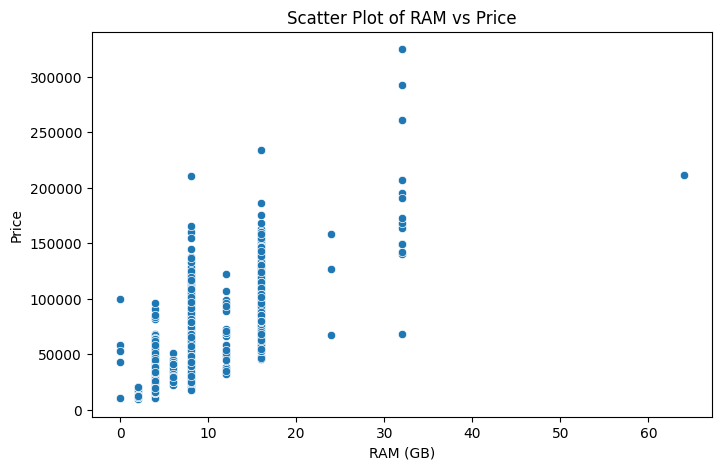

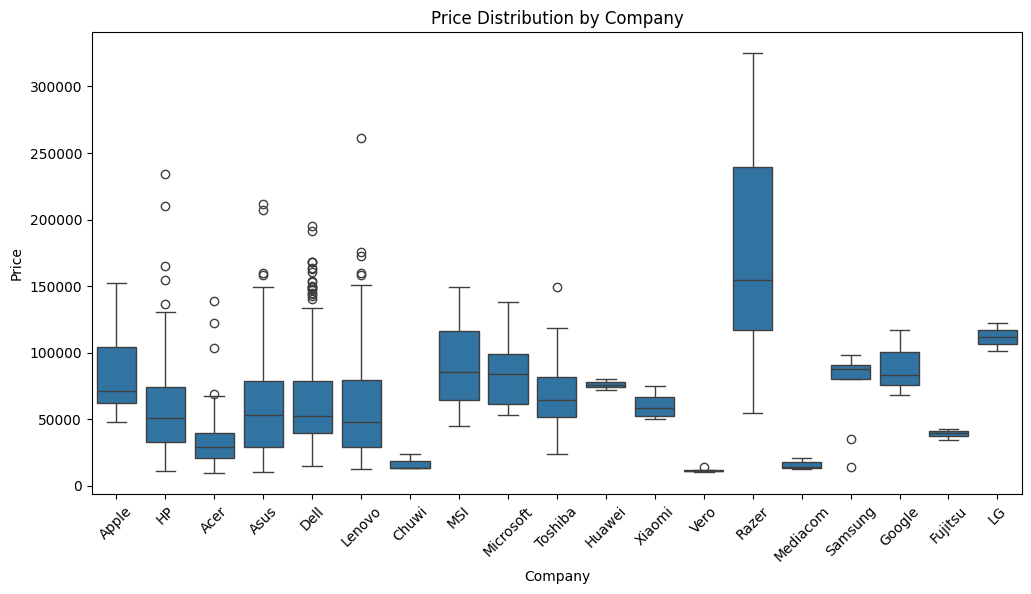

In [8]:
#task 7 visualise
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
# Load dataset
df = pd.read_csv("laptop_data.csv")
os.makedirs("Part1", exist_ok=True)
# Convert Ram to numeric
df["Ram"] = pd.to_numeric(df["Ram"].str.replace("GB", "", regex=False), errors="coerce")
#line chart
plt.figure(figsize=(8,5))
plt.plot(df.index, df["Price"])
plt.title("Line Plot of Laptop Prices")
plt.xlabel("Row Index")
plt.ylabel("Price")
plt.savefig("Part1/line_plot.png", dpi=300, bbox_inches="tight")
plt.show()
#Bar Chart (Average Price by Company)
avg_price = df.groupby("Company")["Price"].mean()

plt.figure(figsize=(10,5))
avg_price.plot(kind="bar")
plt.title("Average Laptop Price by Company")
plt.xlabel("Company")
plt.ylabel("Average Price")
plt.savefig("Part1/bar_chart.png", dpi=300, bbox_inches="tight")
plt.show()
#histogram (Most Skewed Numeric Column)
plt.figure(figsize=(8,5))
sns.histplot(df["Price"], bins=20)
plt.title("Histogram of Laptop Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.savefig("Part1/histogram.png", dpi=300, bbox_inches="tight")
plt.show()
#Scatter Plot (Ram vs Price)
plt.figure(figsize=(8,5))
sns.scatterplot(x="Ram", y="Price", data=df)
plt.title("Scatter Plot of RAM vs Price")
plt.xlabel("RAM (GB)")
plt.ylabel("Price")
plt.savefig("Part1/scatter_plot.png", dpi=300, bbox_inches="tight")
plt.show()
#Box plot(price by company)
plt.figure(figsize=(12,6))
sns.boxplot(x="Company", y="Price", data=df)
plt.title("Price Distribution by Company")
plt.xlabel("Company")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.savefig("Part1/box_plot.png", dpi=300, bbox_inches="tight")
plt.show()

Correlation Matrix:

             sno    Inches       Ram     Price
sno     1.000000 -0.087482 -0.026605  0.069718
Inches -0.087482  1.000000  0.238967  0.069101
Ram    -0.026605  0.238967  1.000000  0.743534
Price   0.069718  0.069101  0.743534  1.000000


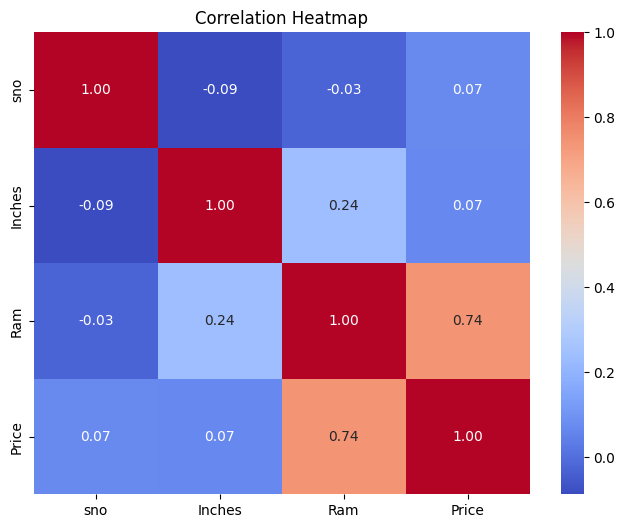


Highest Absolute Correlation:
Variables: ('Ram', 'Price')
Correlation Value: 0.7435336298530848


In [51]:
#task 8  correlation
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load dataset
df = pd.read_csv("laptop_data.csv")

# Convert Ram to numeric
df["Ram"] = pd.to_numeric(df["Ram"].str.replace("GB", "", regex=False), errors="coerce")

# Select numeric columns
numeric_df = df.select_dtypes(include="number")

# Correlation matrix
corr_matrix = numeric_df.corr()

print("Correlation Matrix:\n")
print(corr_matrix)

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Find the pair with the highest absolute correlation
corr = corr_matrix.abs()

# Ignore self-correlation (diagonal)
np.fill_diagonal(corr.values, 0)

highest_pair = corr.unstack().idxmax()
highest_value = corr.unstack().max()

print("\nHighest Absolute Correlation:")
print("Variables:", highest_pair)
print("Correlation Value:", highest_value)

In [52]:
#task 9imputation strategy comparison
import pandas as pd

# Load dataset
df = pd.read_csv("laptop_data.csv")

# Convert Ram to numeric
df["Ram"] = pd.to_numeric(df["Ram"].str.replace("GB", "", regex=False), errors="coerce")

# Convert Price to numeric (if required)
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

# Calculate skewness
skewness = df.select_dtypes(include="number").skew().abs()

# Get the two columns with highest absolute skewness
top2_cols = skewness.sort_values(ascending=False).head(2).index

print("Two numeric columns with highest absolute skewness:")
print(top2_cols)

# Mean and median before imputation
for col in top2_cols:
    print("\nColumn:", col)
    print("Mean   :", df[col].mean())
    print("Median :", df[col].median())

# Fill remaining missing values using the median
for col in top2_cols:
    df[col] = df[col].fillna(df[col].median())

# Verify that no missing values remain
print("\nRemaining missing values:")
print(df[top2_cols].isnull().sum())

Two numeric columns with highest absolute skewness:
Index(['Ram', 'Price'], dtype='object')

Column: Ram
Mean   : 8.384969325153374
Median : 8.0

Column: Price
Mean   : 59898.08367607362
Median : 52054.56

Remaining missing values:
Ram      0
Price    0
dtype: int64


In [53]:
#Task 9 spearman rank correlation
import pandas as pd

# Load dataset
df = pd.read_csv("laptop_data.csv")

# Convert Ram to numeric
df["Ram"] = pd.to_numeric(df["Ram"].str.replace("GB", "", regex=False), errors="coerce")

# Convert Price to numeric (if required)
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

# Calculate skewness
skewness = df.select_dtypes(include="number").skew().abs()

# Get the two columns with highest absolute skewness
top2_cols = skewness.sort_values(ascending=False).head(2).index

print("Two numeric columns with highest absolute skewness:")
print(top2_cols)

# Mean and median before imputation
for col in top2_cols:
    print("\nColumn:", col)
    print("Mean   :", df[col].mean())
    print("Median :", df[col].median())

# Fill remaining missing values using the median
for col in top2_cols:
    df[col] = df[col].fillna(df[col].median())

# Verify that no missing values remain
print("\nRemaining missing values:")
print(df[top2_cols].isnull().sum())

Two numeric columns with highest absolute skewness:
Index(['Ram', 'Price'], dtype='object')

Column: Ram
Mean   : 8.384969325153374
Median : 8.0

Column: Price
Mean   : 59898.08367607362
Median : 52054.56

Remaining missing values:
Ram      0
Price    0
dtype: int64


In [54]:
#show difference between them
df_demo = df.copy()

# Create missing values
df_demo.loc[0:5, "Price"] = None

print("Mean:", df_demo["Price"].mean())
print("Median:", df_demo["Price"].median())

# Mean imputation
mean_df = df_demo.copy()
mean_df["Price"] = mean_df["Price"].fillna(mean_df["Price"].mean())

# Median imputation
median_df = df_demo.copy()
median_df["Price"] = median_df["Price"].fillna(median_df["Price"].median())

print(mean_df["Price"].head(10))
print(median_df["Price"].head(10))

Mean: 59864.859601849
Median: 52054.56
0     59864.859602
1     59864.859602
2     59864.859602
3     59864.859602
4     59864.859602
5     59864.859602
6    114017.601600
7     61735.536000
8     79653.600000
9     41025.600000
Name: Price, dtype: float64
0     52054.5600
1     52054.5600
2     52054.5600
3     52054.5600
4     52054.5600
5     52054.5600
6    114017.6016
7     61735.5360
8     79653.6000
9     41025.6000
Name: Price, dtype: float64


In [56]:
#task 9 show diff, confirm no values
import pandas as pd

# Load dataset
df = pd.read_csv("laptop_data.csv")

# Convert Ram to numeric
df["Ram"] = pd.to_numeric(df["Ram"].str.replace("GB", "", regex=False), errors="coerce")

# Select numeric columns
numeric_df = df.select_dtypes(include="number")

# Find the two columns with the highest absolute skewness
skewness = numeric_df.skew()
top2_cols = skewness.abs().sort_values(ascending=False).head(2).index

print("Two most skewed numeric columns:", list(top2_cols))

# Print mean and median side by side
print("\nMean and Median:")
for col in top2_cols:
    print(f"{col:10} Mean = {df[col].mean():.2f}    Median = {df[col].median():.2f}")

# Median imputation
for col in top2_cols:
    df[col] = df[col].fillna(df[col].median())

# Verify no missing values remain
print("\nRemaining missing values:")
print(df[top2_cols].isnull().sum())

Two most skewed numeric columns: ['Ram', 'Price']

Mean and Median:
Ram        Mean = 8.38    Median = 8.00
Price      Mean = 59898.08    Median = 52054.56

Remaining missing values:
Ram      0
Price    0
dtype: int64


In [57]:
#task 9 grouped aggregation
import pandas as pd

# Load dataset
df = pd.read_csv("laptop_data.csv")

# Group by Company and calculate mean, standard deviation and count of Price
group_stats = df.groupby("Company")["Price"].agg(["mean", "std", "count"])

print(group_stats)

# Group with highest mean
highest_mean_group = group_stats["mean"].idxmax()
highest_mean = group_stats["mean"].max()

# Group with highest standard deviation
highest_std_group = group_stats["std"].idxmax()
highest_std = group_stats["std"].max()

# Ratio of highest mean to lowest mean
lowest_mean = group_stats["mean"].min()
ratio = highest_mean / lowest_mean

print("\nGroup with Highest Mean:", highest_mean_group)
print("Highest Mean:", highest_mean)

print("\nGroup with Highest Standard Deviation:", highest_std_group)
print("Highest Standard Deviation:", highest_std)

print("\nHighest Mean / Lowest Mean Ratio:", round(ratio, 2))

                    mean           std  count
Company                                      
Acer        33200.183576  20016.626618    102
Apple       84734.913600  29925.615589     22
Asus        58684.321087  37355.328672    159
Chuwi       16745.726400   6216.331527      3
Dell        63193.755782  35854.308593    297
Fujitsu     38841.120000   4022.551787      3
Google      89386.080000  25216.998664      3
HP          56891.044222  32900.827893    274
Huawei      75870.720000   5651.197395      2
LG         111834.720000  10656.000000      3
Lenovo      57882.563200  37212.141944    297
MSI         92116.226133  28256.948301     54
Mediacom    15717.600000   3232.124829      7
Microsoft   85903.788000  31884.406736      6
Razer      178282.491429  99100.186173      7
Samsung     75308.320000  29650.823967      9
Toshiba     67549.050000  25516.500285     48
Vero        11584.404000   1546.199768      4
Xiaomi      60390.882000  11198.819633      4

Group with Highest Mean: Razer
Hi

In [9]:
# task 10 SAVE then used in part 2 & 3
# Save the cleaned dataset
df.to_csv("cleaned_data.csv", index=False)

print("Dataset saved successfully as cleaned_data.csv")
cleaned_df = pd.read_csv("cleaned_data.csv")

print(cleaned_df.head())
print(cleaned_df.shape)

Dataset saved successfully as cleaned_data.csv
   sno Company   TypeName  Inches                    ScreenResolution  \
0    0   Apple  Ultrabook    13.3  IPS Panel Retina Display 2560x1600   
1    1   Apple  Ultrabook    13.3                            1440x900   
2    2      HP   Notebook    15.6                   Full HD 1920x1080   
3    3   Apple  Ultrabook    15.4  IPS Panel Retina Display 2880x1800   
4    4   Apple  Ultrabook    13.3  IPS Panel Retina Display 2560x1600   

                          Cpu  Ram               Memory  \
0        Intel Core i5 2.3GHz  NaN                  NaN   
1        Intel Core i5 1.8GHz  NaN  128GB Flash Storage   
2  Intel Core i5 7200U 2.5GHz  NaN            256GB SSD   
3        Intel Core i7 2.7GHz  NaN            512GB SSD   
4        Intel Core i5 3.1GHz  NaN            256GB SSD   

                            Gpu  OpSys  Weight        Price  
0  Intel Iris Plus Graphics 640  macOS  1.37kg   71378.6832  
1        Intel HD Graphics 6000  ma

In [64]:
#saved b4cleaning -show ramtext or numeric
import pandas as pd

# Check the data type
if df["Ram"].dtype == "object":
    df["Ram"] = pd.to_numeric(
        df["Ram"].str.replace("GB", "", regex=False),
        errors="coerce"
    )

print("Ram data type:", df["Ram"].dtype)
print(df["Ram"].head())

# Save the cleaned dataset
df.to_csv("cleaned_data.csv", index=False)

Ram data type: int64
0     8
1     8
2     8
3    16
4     8
Name: Ram, dtype: int64


In [67]:
#null percentage table
import pandas as pd

# Load dataset
df = pd.read_csv("laptop_data1.csv")

# Calculate missing count and percentage
missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100

# Create summary table
null_table = pd.DataFrame({
    "Missing Count": missing_count,
    "Null Percentage (%)": missing_percentage.round(2)
})

# Print all columns
print(null_table)

                  Missing Count  Null Percentage (%)
sno                           0                 0.00
Company                       0                 0.00
TypeName                      0                 0.00
Inches                        1                 0.08
ScreenResolution              0                 0.00
Cpu                           0                 0.00
Ram                          29                 2.22
Memory                       37                 2.84
Gpu                           0                 0.00
OpSys                         0                 0.00
Weight                        0                 0.00
Price                         0                 0.00
